In [1]:
import pandas as pd
from pathlib import Path

# adjust path if needed
parquet_path = Path("data/derivatives/powell_fomc/segments_powell_v3.parquet")
segments = pd.read_parquet(parquet_path)

target_columns = [
    "target__powell",
    "target__chair_powell",
    "target__credit",
    "target__pandemic",
    "target__obvious",
    "target__recession",
    "target__volatility",
    "target__median",
    "target__tax",
    "target__restrictive",
    "target__goods_inflation",
    "target__balance_sheet",
    "target__growth",
    "target__balance_of_risk",
    "target__probability",
    "target__pardon",
    "target__anchor",
    "target__gold",
    "target__bitcoin",
    "target__national_debt",
    "target__soft_landing",
    "target__trade_war",
    "target__yield_curve",
    "target__data",
    "target__good_afternoon",
    "target__expectation",
    "target__projection",
    "target__egg",
    "target__fort_knox",
    "target__qt",
    "target__qe",
    "target__quantitative_tightening",
    "target__quantitative_easing",
    "target__trump",
    "target__consumer_confidence",
    "target__dot_plot",
    "target__beige_book",
    "target__uncertainty",
    "target__tariff_inflation",
    "target__tariff",
    "target__unchanged",
]



In [2]:
# event-level label = did he say it at least once in that conference?
event_flags = (
    segments.groupby("event_id")[target_columns]
    .max()
    .reset_index()
)

# compute base rate across events for each target, sorted
base_rates = (
    event_flags[target_columns]
    .mean()
    .sort_values(ascending=False)
    .rename("historical_prob")
    .to_frame()
)
base_rates.index = base_rates.index.str.replace("target__", "", regex=False)
base_rates


,historical_prob
powell,1.000000
chair_powell,1.000000
data,1.000000
growth,0.967742
expectation,0.967742
good_afternoon,0.935484
pandemic,0.935484
restrictive,0.935484
uncertainty,0.838710
balance_sheet,0.806452


In [3]:
# event-level *counts* (instead of indicator flags)
event_Ncounts = (
    segments.groupby("event_id")[target_columns]
    .sum()
    .reset_index()
)

# compute base rate across events for each target, sorted
Ncounts = (
    event_Ncounts[target_columns]
    .mean()
    .sort_values(ascending=False)
    .rename("avg_num")
    .to_frame()
)
Ncounts.index = Ncounts.index.str.replace("target__", "", regex=False)
Ncounts

,avg_num
powell,37.193548
chair_powell,37.032258
data,11.709677
growth,8.290323
expectation,6.290323
restrictive,5.774194
pandemic,3.419355
uncertainty,3.193548
projection,3.161290
tariff,3.000000


In [4]:
target = "target__credit"  # change as needed

# per-event indicator + optional dates if present
cols = ["event_id", target]
if "event_date" in segments.columns:
    cols.append("event_date")

ev = (
    segments[cols]
    .groupby("event_id", as_index=False)
    .max()
    .sort_values(cols[-1] if "event_date" in cols else "event_id")
    .rename(columns={target: "mentioned"})
)

ev

,event_id,mentioned,event_date
4,FOMC_JAN2022,False,2022-01-26
15,FOMC_MAR2022,True,2022-03-16
19,FOMC_MAY2022,True,2022-05-04
11,FOMC_JUN2022,True,2022-06-15
7,FOMC_JUL2022,False,2022-07-27
26,FOMC_SEP2022,True,2022-09-21
23,FOMC_NOV2022,True,2022-11-02
0,FOMC_DEC2022,True,2022-12-14
3,FOMC_FEB2023,False,2023-02-01
16,FOMC_MAR2023,True,2023-03-22


In [5]:
ev_counts = (
    segments[cols]
    .groupby(["event_id", "event_date"] if "event_date" in segments.columns else "event_id")
    .sum()
    .reset_index()
    .sort_values("event_date" if "event_date" in segments.columns else "event_id")
    .rename(columns={target: "mention_count"})
)

ev_counts

,event_id,event_date,mention_count
4,FOMC_JAN2022,2022-01-26,0
15,FOMC_MAR2022,2022-03-16,1
19,FOMC_MAY2022,2022-05-04,1
11,FOMC_JUN2022,2022-06-15,2
7,FOMC_JUL2022,2022-07-27,0
26,FOMC_SEP2022,2022-09-21,2
23,FOMC_NOV2022,2022-11-02,2
0,FOMC_DEC2022,2022-12-14,1
3,FOMC_FEB2023,2023-02-01,0
16,FOMC_MAR2023,2023-03-22,15


In [6]:
import numpy as np

def wilson_interval(k, n, z=1.96):  # 95% CI by default
    if n == 0:
        return (0.0, 1.0)
    phat = k / n
    denom = 1 + z**2 / n
    centre = phat + z**2 / (2*n)
    adj = z * np.sqrt((phat*(1-phat) + z**2/(4*n)) / n)
    lo = (centre - adj) / denom
    hi = (centre + adj) / denom
    return float(max(0, lo)), float(min(1, hi))

# build CI table for all targets
event_counts = (segments.groupby("event_id")[target_columns].max())
n_events = len(event_counts)

rows = []
for tc in target_columns:
    k = int(event_counts[tc].sum())  # number of events where mentioned ≥1x
    lo, hi = wilson_interval(k, n_events)
    rows.append({"target": tc.replace("target__", ""), "k": k, "n": n_events,
                 "prob": k/n_events, "ci_lo": lo, "ci_hi": hi})

ci_df = pd.DataFrame(rows).sort_values("prob", ascending=False).reset_index(drop=True)
ci_df

,target,k,n,prob,ci_lo,ci_hi
0,powell,31,31,1.000000,0.889741,1.000000
1,chair_powell,31,31,1.000000,0.889741,1.000000
2,data,31,31,1.000000,0.889741,1.000000
3,growth,30,31,0.967742,0.838055,0.994283
4,expectation,30,31,0.967742,0.838055,0.994283
5,good_afternoon,29,31,0.935484,0.792810,0.982126
6,pandemic,29,31,0.935484,0.792810,0.982126
7,restrictive,29,31,0.935484,0.792810,0.982126
8,uncertainty,26,31,0.838710,0.673653,0.929075
9,balance_sheet,25,31,0.806452,0.637194,0.908131


ValueError: 'yerr' must not contain negative values

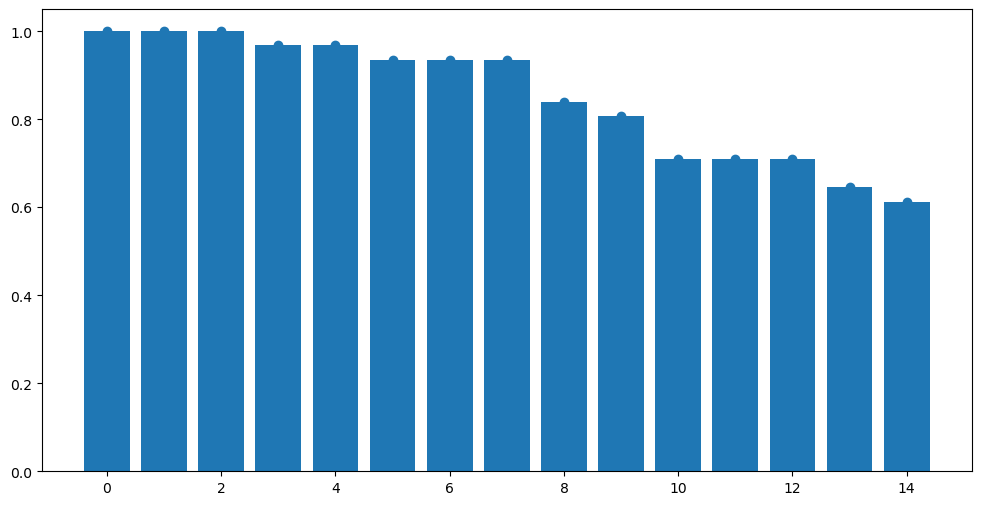

In [7]:
import matplotlib.pyplot as plt

top_n = 15
top = ci_df.head(top_n).copy()

x = np.arange(len(top))
y = top["prob"].values
yerr = np.vstack([y - top["ci_lo"].values, top["ci_hi"].values - y])

plt.figure(figsize=(12, 6))
plt.bar(x, y)
plt.errorbar(x, y, yerr=yerr, fmt='o', capsize=4)
plt.xticks(x, top["target"].tolist(), rotation=45, ha="right")
plt.ylabel("Historical P(mention ≥1x)")
plt.title(f"Powell — Top {top_n} phrase base rates (95% Wilson CI)")
plt.tight_layout()
plt.show()


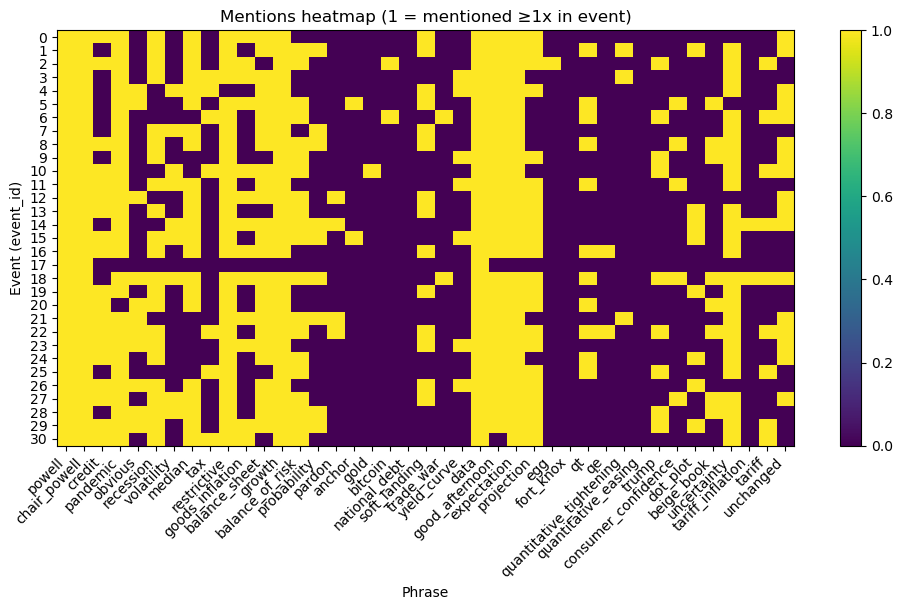

In [ ]:
# subset_targets = [
#     "target__credit", "target__recession",
#     "target__inflation" if "target__inflation" in event_flags.columns else "target__growth",
#     "target__balance_sheet", "target__yield_curve", "target__bitcoin", "target__gold"
# ]
subset_targets = [t for t in target_columns if t in event_flags.columns]

if "event_date" in segments.columns:
    ev_dates = segments[["event_id", "event_date"]].drop_duplicates().set_index("event_id")
    ev_flags = event_flags.join(ev_dates, how="left").sort_values("event_date")
else:
    ev_flags = event_flags.copy()

if subset_targets:
    mat = ev_flags[subset_targets].astype(int).values
    plt.figure(figsize=(10, max(4, mat.shape[0]*0.2)))
    plt.imshow(mat, aspect="auto", interpolation="nearest")
    plt.yticks(np.arange(ev_flags.shape[0]), ev_flags.index.tolist())
    plt.xticks(np.arange(len(subset_targets)), [t.replace("target__", "") for t in subset_targets], rotation=45, ha="right")
    plt.xlabel("Phrase")
    plt.ylabel("Event (event_id)")
    plt.title("Mentions heatmap (1 = mentioned ≥1x in event)")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


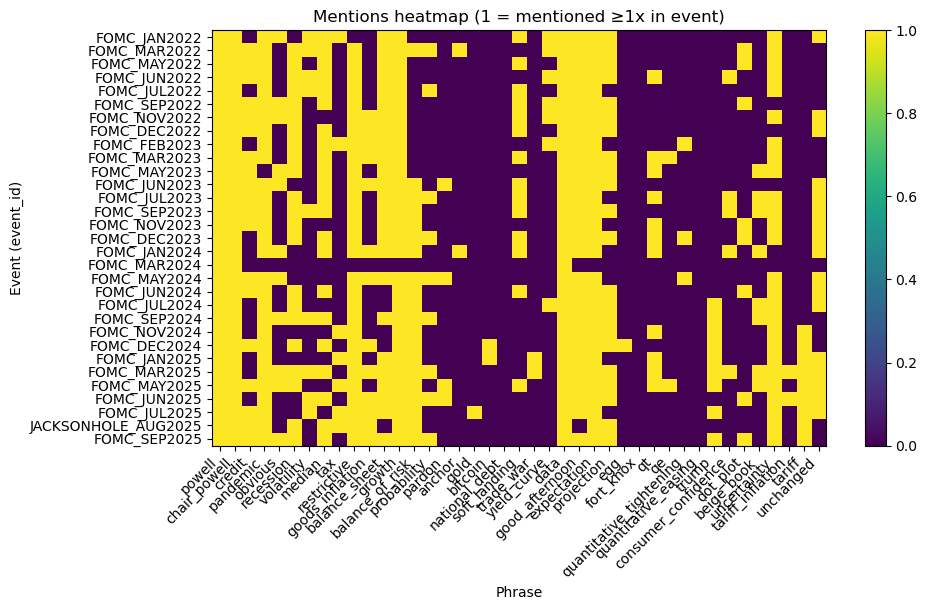

In [ ]:
subset_targets = [t for t in target_columns if t in event_flags.columns]

# 1) Build canonical chronological order from segments
events = (
    segments[["event_id", "event_date"]]
    .drop_duplicates()
    .assign(event_date=pd.to_datetime(segments["event_date"]))
    .sort_values("event_date")
)

row_order = events["event_id"].tolist()  # e.g., ["1Q23_EARNINGS","2Q23_EARNINGS",...]

# 2) Make sure ev_flags is indexed by event_id, then reindex to chronological order
ev_flags = event_flags.copy()
if ev_flags.index.name != "event_id":
    ev_flags = ev_flags.reset_index().rename(columns={ev_flags.index.name: "event_id"}).set_index("event_id")

ev_flags = ev_flags.reindex(row_order)

# (optional) keep event_date for reference/debug, not used for ordering anymore
ev_flags = ev_flags.join(events.set_index("event_id")["event_date"], how="left")

# 3) Plot
if subset_targets:
    mat = ev_flags[subset_targets].astype(int).values
    plt.figure(figsize=(10, max(4, mat.shape[0]*0.2)))
    plt.imshow(mat, aspect="auto", interpolation="nearest")
    plt.yticks(np.arange(ev_flags.shape[0]), ev_flags.index.tolist())  # now chronological
    plt.xticks(
        np.arange(len(subset_targets)),
        [t.replace("target__", "") for t in subset_targets],
        rotation=45, ha="right"
    )
    plt.xlabel("Phrase")
    plt.ylabel("Event (event_id)")
    plt.title("Mentions heatmap (1 = mentioned ≥1x in event)")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


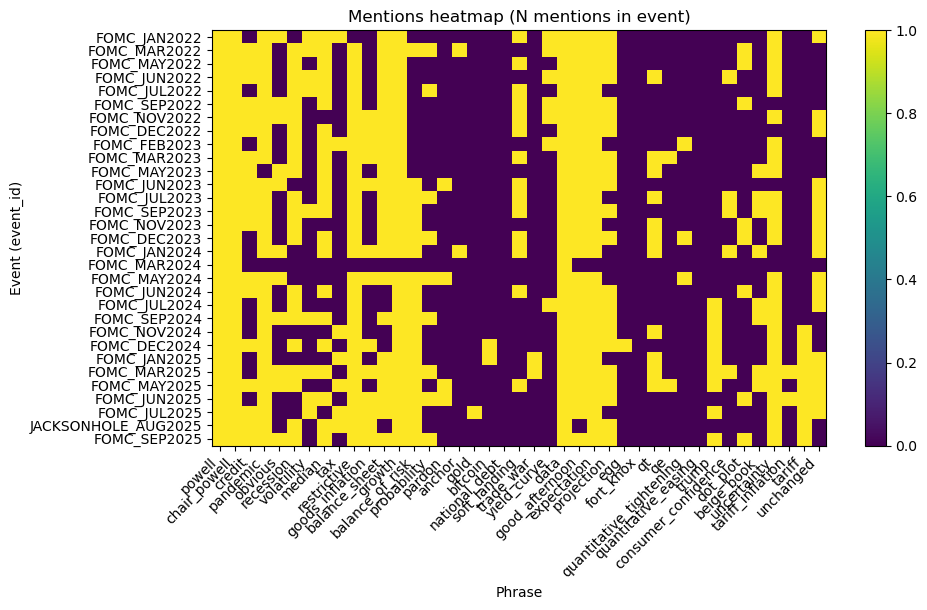

In [ ]:
ev_counts = event_Ncounts.copy()
if ev_counts.index.name != "event_id":
    ev_counts = ev_counts.reset_index().rename(columns={ev_counts.index.name: "event_id"}).set_index("event_id")

ev_counts = ev_counts.reindex(row_order)

# (optional) keep event_date for reference/debug, not used for ordering anymore
ev_counts = ev_counts.join(events.set_index("event_id")["event_date"], how="left")

# 3) Plot
if subset_targets:
    mat = ev_counts[subset_targets].values
    plt.figure(figsize=(10, max(4, mat.shape[0]*0.2)))
    plt.imshow(mat, aspect="auto", interpolation="nearest")
    plt.yticks(np.arange(ev_counts.shape[0]), ev_counts.index.tolist())  # now chronological
    plt.xticks(
        np.arange(len(subset_targets)),
        [t.replace("target__", "") for t in subset_targets],
        rotation=45, ha="right"
    )
    plt.xlabel("Phrase")
    plt.ylabel("Event (event_id)")
    plt.title("Mentions heatmap (N mentions in event)")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

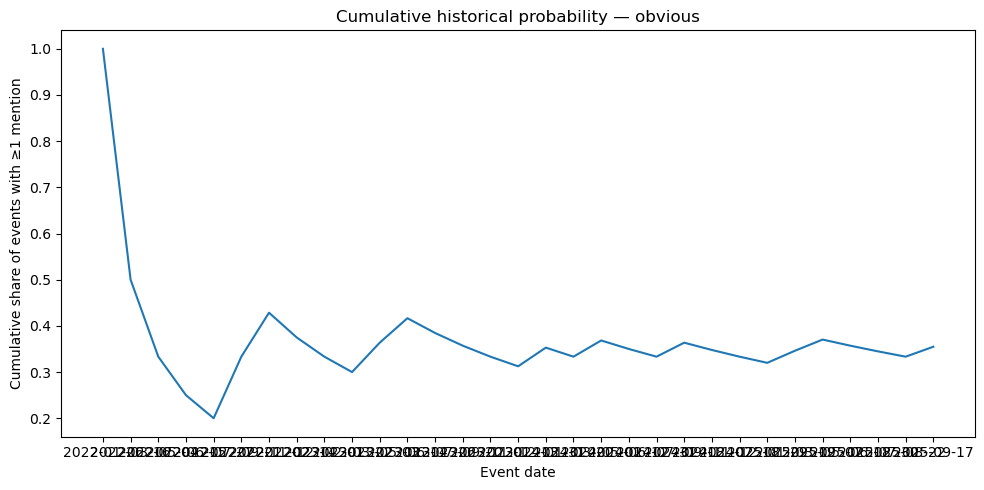

In [ ]:
target = "target__obvious"  # change freely

if "event_date" in segments.columns:
    ev = segments[["event_id","event_date",target]].groupby(["event_id","event_date"], as_index=False).max().sort_values("event_date")
    x = ev["event_date"]
else:
    ev = segments[["event_id",target]].groupby("event_id", as_index=False).max().sort_values("event_id")
    ev["idx"] = np.arange(1, len(ev)+1)
    x = ev["idx"]

ev["cum_mentioned"] = ev[target].cumsum()
ev["cum_share"] = ev["cum_mentioned"] / (np.arange(1, len(ev)+1))

plt.figure(figsize=(10,5))
plt.plot(x, ev["cum_share"])
plt.xlabel("Event date" if "event_date" in segments.columns else "Event index")
plt.ylabel("Cumulative share of events with ≥1 mention")
plt.title(f"Cumulative historical probability — {target.replace('target__','')}")
plt.tight_layout()
plt.show()


In [ ]:
def implied_prob_from_decimal(decimal_odds: float) -> float:
    return 1.0 / decimal_odds

def kelly_edge(bp: float, mp: float) -> float:
    # Kelly numerator: (bp - mp) / (1 - mp); >0 → +EV
    return (bp - mp) / (1 - mp)

# Example: market offers YES at 1.80 (≈55.6%)
phrase = "obvious"
my_p = float(ci_df.loc[ci_df["target"]==phrase, "prob"])
conservative_p = float(ci_df.loc[ci_df["target"]==phrase, "ci_lo"])

# market_decimal = 1.80
# market_p = implied_prob_from_decimal(market_decimal)
market_p = 0.43

print({
    "phrase": phrase,
    "my_prob": round(my_p, 3),
    "conservative_prob": round(conservative_p, 3),
    "market_prob": round(market_p, 3),
    "edge_prob_based": round(kelly_edge(my_p, market_p), 4),
    "edge_conservative": round(kelly_edge(conservative_p, market_p), 4),
})


{'phrase': 'obvious', 'my_prob': 0.355, 'conservative_prob': 0.211, 'market_prob': 0.43, 'edge_prob_based': -0.1319, 'edge_conservative': -0.3839}


/var/folders/p3/svv3_rhn7mlfyw2x0bgcq_k40000gn/T/ipykernel_54400/1779216632.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  my_p = float(ci_df.loc[ci_df["target"]==phrase, "prob"])
/var/folders/p3/svv3_rhn7mlfyw2x0bgcq_k40000gn/T/ipykernel_54400/1779216632.py:11: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  conservative_p = float(ci_df.loc[ci_df["target"]==phrase, "ci_lo"])


In [ ]:
import json, statistics as stats
from pathlib import Path

exp_dir = Path("experiments/powell_baseline3")
files = sorted(exp_dir.glob("fold_*_metrics.json"))

metrics = []
for fp in files:
    with open(fp) as f:
        j = json.load(f)
    # keep the common ones
    metrics.append({
        "file": fp.name,
        "log_loss": j.get("log_loss"),
        "brier": j.get("brier"),
        "roc_auc": j.get("roc_auc"),
        "avg_prec": j.get("average_precision"),
        "accuracy": j.get("accuracy"),
        "precision": j.get("precision"),
        "recall": j.get("recall"),
        "f1": j.get("f1"),
    })

m = pd.DataFrame(metrics)
summary = m.describe().loc[["mean","min","max"]]
m, summary


(                    file  log_loss     brier   roc_auc  avg_prec  accuracy  \
 0    fold_0_metrics.json  0.228023  0.048979  0.883721  0.166667  0.977273   
 1   fold_10_metrics.json  0.180767  0.031434  1.000000  1.000000  0.977273   
 2   fold_11_metrics.json  0.212360  0.042291  1.000000  1.000000  0.961538   
 3   fold_12_metrics.json  0.254537  0.059086  0.983333  0.854167  0.959184   
 4   fold_13_metrics.json  0.169859  0.026588  1.000000  1.000000  1.000000   
 5   fold_14_metrics.json  0.187208  0.030509       NaN  0.000000  1.000000   
 6   fold_15_metrics.json  0.218798  0.043289  0.980000  0.500000  0.980392   
 7   fold_16_metrics.json  0.478765  0.158198  0.955556  0.949593  0.714286   
 8   fold_17_metrics.json  0.174120  0.025537       NaN  0.000000  1.000000   
 9   fold_18_metrics.json  0.196717  0.033246       NaN  0.000000  1.000000   
 10  fold_19_metrics.json  0.213730  0.040590  1.000000  1.000000  0.977273   
 11   fold_1_metrics.json  0.199535  0.035090       

In [ ]:
for _, r in ci_df.iterrows():
    print(f"{r['target']:<22} prob={r['prob']:.3f}  CI95%[{r['ci_lo']:.3f},{r['ci_hi']:.3f}]  k/n={r['k']}/{r['n']}")


powell                 prob=1.000  CI95%[0.890,1.000]  k/n=31/31
chair_powell           prob=1.000  CI95%[0.890,1.000]  k/n=31/31
data                   prob=1.000  CI95%[0.890,1.000]  k/n=31/31
growth                 prob=0.968  CI95%[0.838,0.994]  k/n=30/31
expectation            prob=0.968  CI95%[0.838,0.994]  k/n=30/31
good_afternoon         prob=0.935  CI95%[0.793,0.982]  k/n=29/31
pandemic               prob=0.935  CI95%[0.793,0.982]  k/n=29/31
restrictive            prob=0.935  CI95%[0.793,0.982]  k/n=29/31
uncertainty            prob=0.839  CI95%[0.674,0.929]  k/n=26/31
balance_sheet          prob=0.806  CI95%[0.637,0.908]  k/n=25/31
median                 prob=0.710  CI95%[0.534,0.839]  k/n=22/31
recession              prob=0.710  CI95%[0.534,0.839]  k/n=22/31
projection             prob=0.710  CI95%[0.534,0.839]  k/n=22/31
balance_of_risk        prob=0.645  CI95%[0.469,0.789]  k/n=20/31
credit                 prob=0.613  CI95%[0.438,0.763]  k/n=19/31
unchanged              pr